In [3]:
import pandas as pd

#read excel dataset

df_employer = pd.read_excel(r'C:\Users\User\Desktop\youth unemployement\Cleaned_Employers_Perspectives_on_Youth_Unemployment.xlsx')

In [4]:
print(df_employer.columns.tolist())

['emp_id', 'industry', 'organization_size', 'hiring_role', 'youth_hired_12m', 'hiring_challenges', 'recruitment_sources', 'top_interview_factors', 'reasons_not_selected', 'importance_technical_skills', 'importance_practical_experience', 'importance_communication', 'importance_problem_solving', 'importance_ability_to_learn', 'importance_degree', 'importance_previous_internship', 'importance_language_skills', 'entry_level_job_availability', 'expected_previous_experience', 'response_to_skill_gap', 'importance_connections', 'university_preference', 'unnecessary_requirements', 'youth_turnover_reasons', 'employment_improvements', 'hiring_challenges__candidates_expected_higher_salaries_than_we_could_offer', 'hiring_challenges__candidates_lacked_the_experience_we_expected', 'hiring_challenges__candidates_lacked_the_skills_we_needed', 'hiring_challenges__candidates_were_unavailable_because_of_location_transportation_or_working_hours', 'hiring_challenges__suitable_candidates_accepted_but_later_l

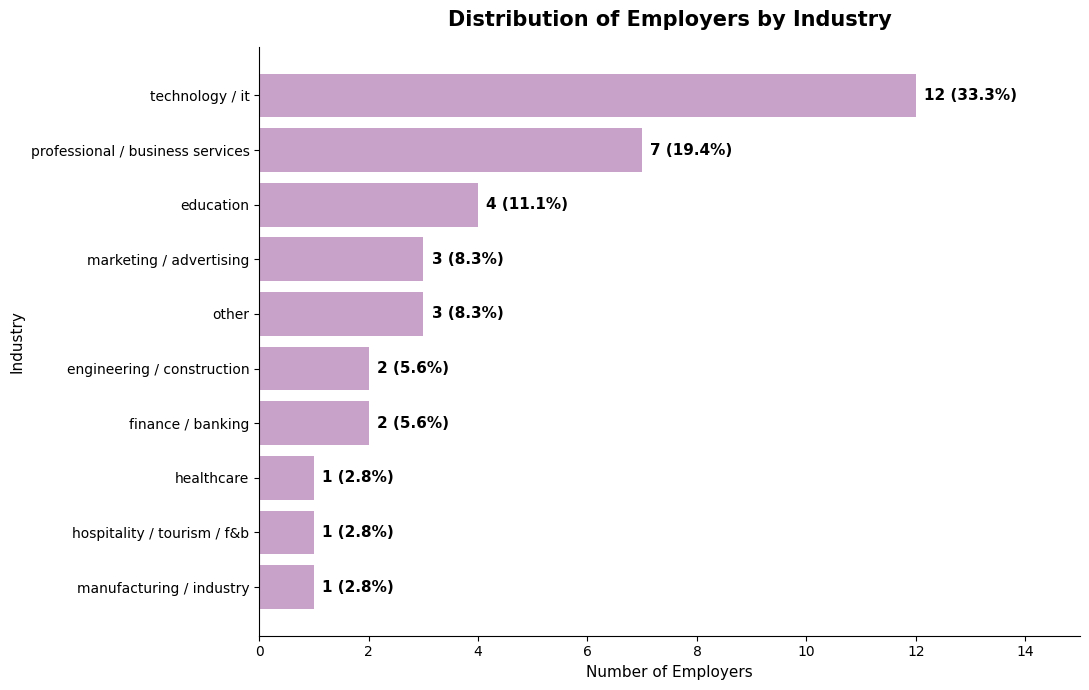

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# Employer Industry Distribution
# =========================================================

industry = df_employer["industry"].fillna("Missing")

# Counts and percentages
industry_counts = industry.value_counts()
industry_percentages = industry.value_counts(normalize=True) * 100

industry_summary = pd.DataFrame({
    "Industry": industry_counts.index,
    "Count": industry_counts.values,
    "Percentage": industry_percentages.values
})

# =========================================================
# Horizontal Bar Chart
# =========================================================

fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.barh(
    industry_summary["Industry"],
    industry_summary["Count"],
    color="#C8A2C8"
)

# Put largest category at the top
ax.invert_yaxis()

# Add Count + Percentage labels
for bar, count, percentage in zip(
    bars,
    industry_summary["Count"],
    industry_summary["Percentage"]
):
    ax.text(
        bar.get_width() + 0.15,
        bar.get_y() + bar.get_height() / 2,
        f"{int(count)} ({percentage:.1f}%)",
        va="center",
        ha="left",
        fontsize=11,
        fontweight="bold"
    )

# Titles and labels
ax.set_title(
    "Distribution of Employers by Industry",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Number of Employers", fontsize=11)
ax.set_ylabel("Industry", fontsize=11)

# Make enough room for labels
max_count = industry_summary["Count"].max()
ax.set_xlim(0, max_count * 1.25)

# Clean presentation
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# Save
plt.savefig(
    "figures/employer_industry.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



                           Industry  Count  Percentage
0                   technology / it     12        33.3
1  professional / business services      7        19.4
2                         education      4        11.1
3           marketing / advertising      3         8.3
4                             other      3         8.3
5        engineering / construction      2         5.6
6                 finance / banking      2         5.6
7                        healthcare      1         2.8
8       hospitality / tourism / f&b      1         2.8
9          manufacturing / industry      1         2.8


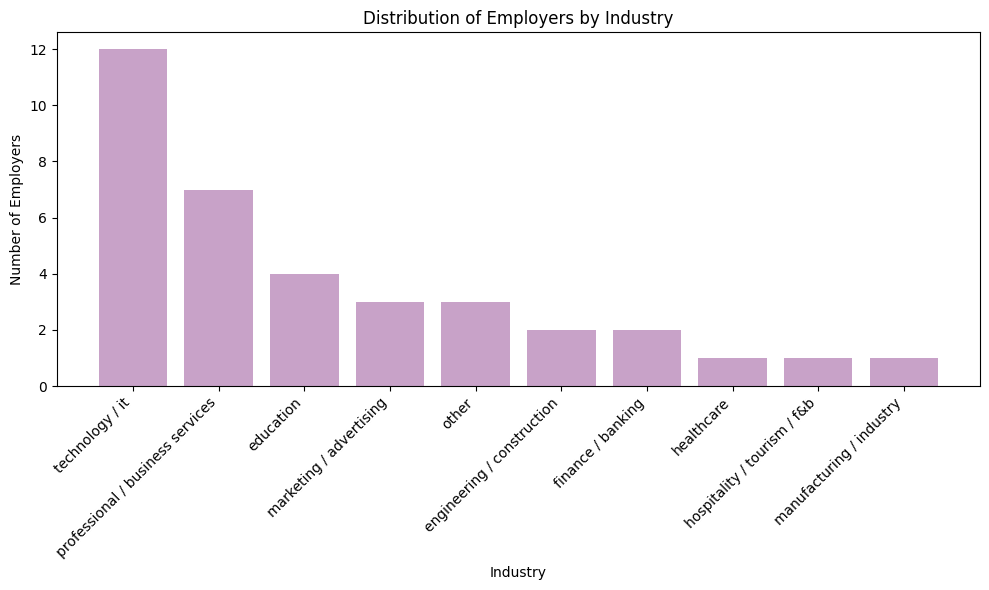



#figure(
  table(
    columns: (1fr, 1.5cm, 2cm),
    align: (left, center, center),
    inset: 8pt,
    stroke: 0.5pt + rgb("#D9D9D9"),

    table.header(
      [*Industry*],
      [*Count*],
      [*Percentage*],
    ),

    [technology / it],
    [12],
    [33.3%],
    [professional / business services],
    [7],
    [19.4%],
    [education],
    [4],
    [11.1%],
    [marketing / advertising],
    [3],
    [8.3%],
    [other],
    [3],
    [8.3%],
    [engineering / construction],
    [2],
    [5.6%],
    [finance / banking],
    [2],
    [5.6%],
    [healthcare],
    [1],
    [2.8%],
    [hospitality / tourism / f\&b],
    [1],
    [2.8%],
    [manufacturing / industry],
    [1],
    [2.8%],
  ),
  caption: [
    Distribution of employers by industry.
  ],
) <tab:employer-industry>



In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# Employer Industry Distribution
# =========================================================

# Use the exact feature name
industry = df_employer["industry"].copy()

# Treat missing values as a separate category
industry = industry.fillna("Missing")

# Count and percentage
industry_counts = industry.value_counts()
industry_percentages = industry.value_counts(normalize=True) * 100

# Create summary dataframe
industry_summary = pd.DataFrame({
    "Industry": industry_counts.index,
    "Count": industry_counts.values,
    "Percentage": industry_percentages.values.round(1)
})

print(industry_summary)


# =========================================================
# Bar Chart
# =========================================================

plt.figure(figsize=(10, 6))

plt.bar(
    industry_summary["Industry"],
    industry_summary["Count"],
    color="#C8A2C8"
)

plt.title("Distribution of Employers by Industry")
plt.xlabel("Industry")
plt.ylabel("Number of Employers")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

# Save for Typst
plt.savefig(
    "figures/employer_industry.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =========================================================
# Generate Typst Table
# =========================================================

typst_rows = []

for _, row in industry_summary.iterrows():

    industry_name = str(row["Industry"])

    # Escape Typst special characters if needed
    industry_name = (
        industry_name
        .replace("\\", "\\\\")
        .replace("%", "\\%")
        .replace("&", "\\&")
        .replace("#", "\\#")
    )

    typst_rows.append(
        f"    [{industry_name}],\n"
        f"    [{int(row['Count'])}],\n"
        f"    [{row['Percentage']:.1f}%],"
    )

typst_table = f"""
#figure(
  table(
    columns: (1fr, 1.5cm, 2cm),
    align: (left, center, center),
    inset: 8pt,
    stroke: 0.5pt + rgb("#D9D9D9"),

    table.header(
      [*Industry*],
      [*Count*],
      [*Percentage*],
    ),

{chr(10).join(typst_rows)}
  ),
  caption: [
    Distribution of employers by industry.
  ],
) <tab:employer-industry>
"""

print("\n" + typst_table)

  Organization Size  Count  Percentage
0             11–50     11   30.555556
1            51–250     11   30.555556
2              1–10      9   25.000000
3     more than 500      4   11.111111
4           251–500      1    2.777778


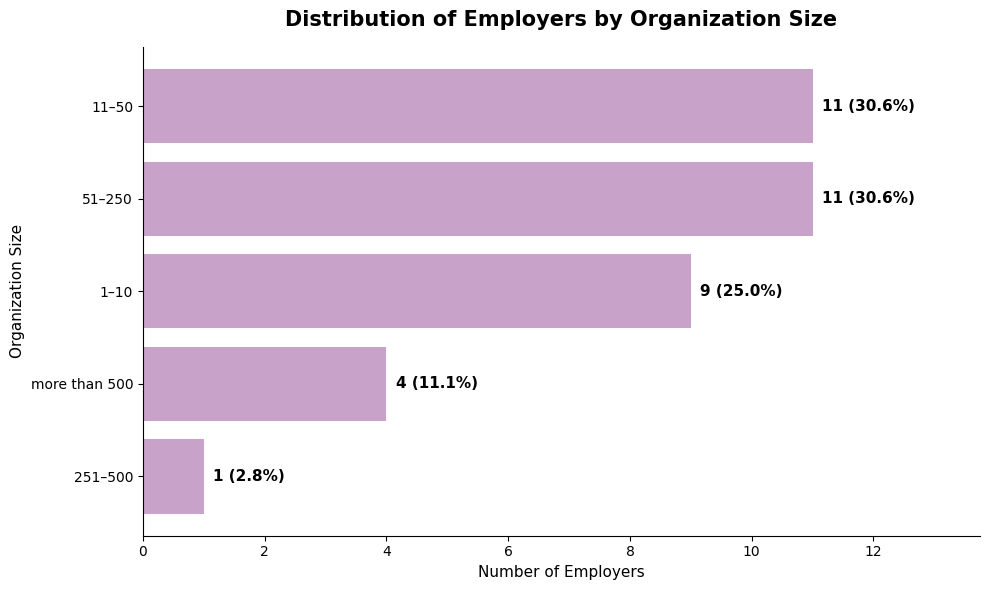

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# Employer Organization Size Distribution
# =========================================================

organization_size = df_employer["organization_size"].fillna("Missing")

# Counts and percentages
size_counts = organization_size.value_counts()
size_percentages = organization_size.value_counts(normalize=True) * 100

size_summary = pd.DataFrame({
    "Organization Size": size_counts.index,
    "Count": size_counts.values,
    "Percentage": size_percentages.values
})

print(size_summary)


# =========================================================
# Horizontal Bar Chart
# =========================================================

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    size_summary["Organization Size"],
    size_summary["Count"],
    color="#C8A2C8"
)

# Largest category at the top
ax.invert_yaxis()

# Add count + percentage labels
for bar, count, percentage in zip(
    bars,
    size_summary["Count"],
    size_summary["Percentage"]
):
    ax.text(
        bar.get_width() + 0.15,
        bar.get_y() + bar.get_height() / 2,
        f"{int(count)} ({percentage:.1f}%)",
        va="center",
        ha="left",
        fontsize=11,
        fontweight="bold"
    )

# Titles and labels
ax.set_title(
    "Distribution of Employers by Organization Size",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Number of Employers", fontsize=11)
ax.set_ylabel("Organization Size", fontsize=11)

# Leave space for count + percentage labels
max_count = size_summary["Count"].max()
ax.set_xlim(0, max_count * 1.25)

# Clean appearance
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# Save high-quality figure
plt.savefig(
    "figures/employer_size.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [15]:
import pandas as pd

# Define the correct ordinal order
size_order = [
    "1–10",
    "11–50",
    "51–250",
    "251–500",
    "more than 500"
]

# Convert to ordered categorical
size = pd.Categorical(
    df_employer["organization_size"],
    categories=size_order,
    ordered=True
)

# Convert categories to ordinal numeric codes
size_codes = pd.Series(size).cat.codes

# Remove missing values (-1)
size_codes = size_codes[size_codes != -1]

# Calculate median ordinal position
median_code = size_codes.median()

# Convert median code back to category
median_size = size_order[int(median_code)]

print("Median organization size:", median_size)

Median organization size: 11–50


                  Hiring Role  Count  Percentage
0             department head     12   33.333333
1            hr / recruitment      8   22.222222
2  hiring manager / team lead      7   19.444444
3             owner / founder      7   19.444444
4                       other      2    5.555556


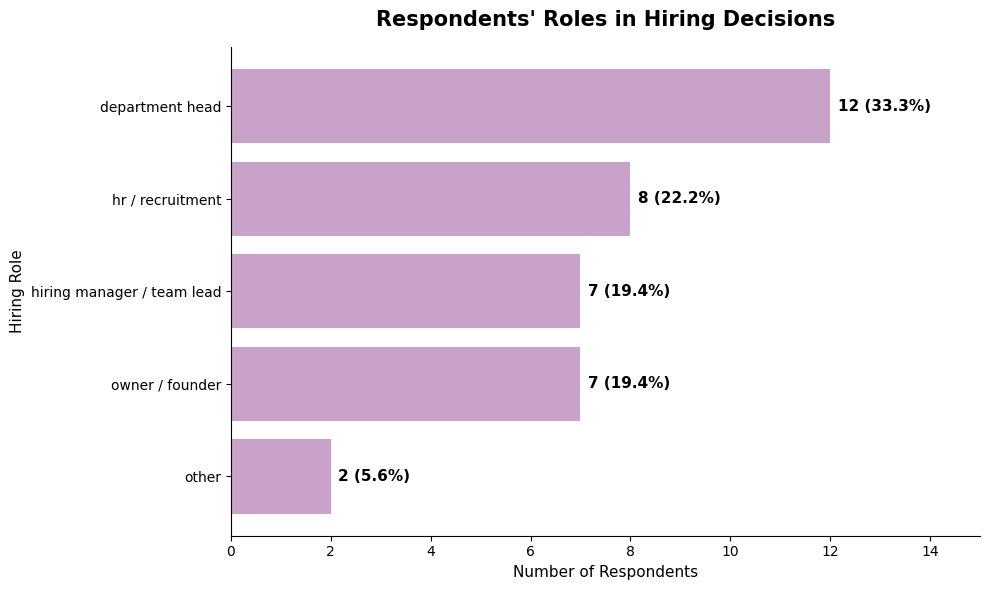

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# Hiring Role Distribution
# =========================================================

hiring_role = df_employer["hiring_role"].fillna("Missing")

# Counts and percentages
role_counts = hiring_role.value_counts()
role_percentages = hiring_role.value_counts(normalize=True) * 100

role_summary = pd.DataFrame({
    "Hiring Role": role_counts.index,
    "Count": role_counts.values,
    "Percentage": role_percentages.values
})

print(role_summary)


# =========================================================
# Horizontal Bar Chart
# =========================================================

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    role_summary["Hiring Role"],
    role_summary["Count"],
    color="#C8A2C8"
)

# Largest category at the top
ax.invert_yaxis()

# Add count + percentage labels
for bar, count, percentage in zip(
    bars,
    role_summary["Count"],
    role_summary["Percentage"]
):
    ax.text(
        bar.get_width() + 0.15,
        bar.get_y() + bar.get_height() / 2,
        f"{int(count)} ({percentage:.1f}%)",
        va="center",
        ha="left",
        fontsize=11,
        fontweight="bold"
    )

# Titles and labels
ax.set_title(
    "Respondents' Roles in Hiring Decisions",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Number of Respondents", fontsize=11)
ax.set_ylabel("Hiring Role", fontsize=11)

# Space for labels
max_count = role_summary["Count"].max()
ax.set_xlim(0, max_count * 1.25)

# Clean appearance
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# Save high-quality figure
plt.savefig(
    "figures/employer_hiring_role.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
import pandas as pd

# =========================================================
# Number of Young People Hired — Median Analysis
# =========================================================

# Check the actual categories first
print(df_employer["youth_hired_12m"].unique())

# Define the ordinal order
hiring_order = [
    "none",
    "1–2",
    "3–5",
    "6–10",
    "11–20",
    "more than 20"
]

# Convert to ordered categorical
hiring = pd.Categorical(
    df_employer["youth_hired_12m"],
    categories=hiring_order,
    ordered=True
)

# Convert to ordinal numeric codes
hiring_codes = pd.Series(hiring).cat.codes

# Remove missing values
hiring_codes = hiring_codes[hiring_codes != -1]

# Calculate median ordinal position
median_code = hiring_codes.median()

# Convert median code back to category
median_hiring = hiring_order[int(median_code)]

print("Median number of young people hired:", median_hiring)

['3–5' 'more than 10' 'none' '6–10' '1–2']
Median number of young people hired: 3–5


Median number of young people hired: 3–5


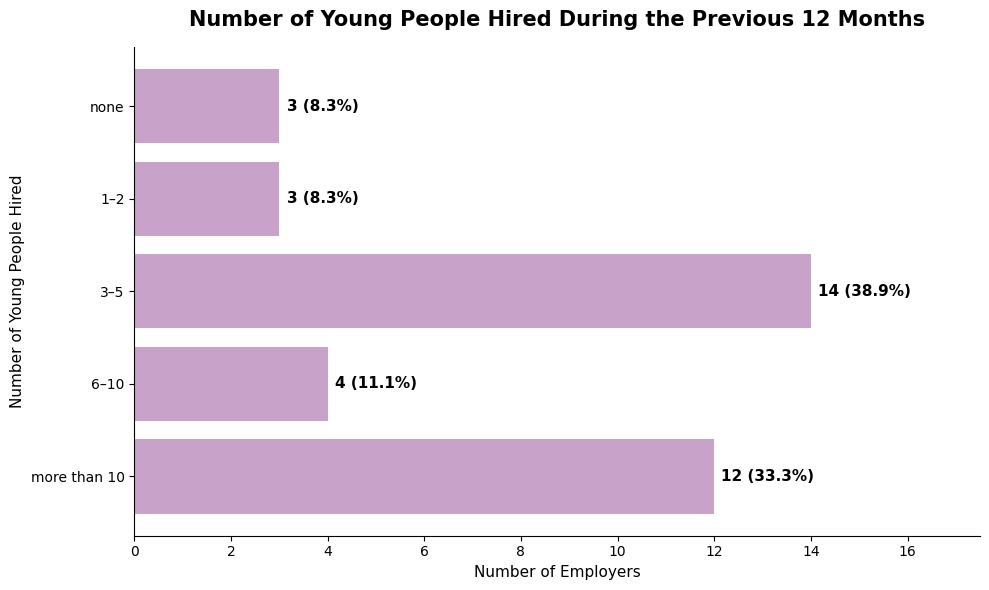

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# Number of Young People Hired — Ordinal Variable
# =========================================================

hiring = df_employer["youth_hired_12m"]

# Define the correct ordinal order
categories = [
    "none",
    "1–2",
    "3–5",
    "6–10",
    "more than 10"
]

# Convert to ordered categorical variable
ordered_hiring = pd.Categorical(
    hiring,
    categories=categories,
    ordered=True
)

# =========================================================
# Median calculation
# =========================================================

codes = pd.Series(ordered_hiring).cat.codes
codes = codes[codes != -1]  # remove missing values

median_code = codes.median()
median_category = categories[int(median_code)]

print("Median number of young people hired:", median_category)

# =========================================================
# Distribution for visualization
# =========================================================

counts = hiring.value_counts().reindex(
    categories,
    fill_value=0
)

percentages = counts / counts.sum() * 100

# =========================================================
# Visualization
# =========================================================

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    categories,
    counts,
    color="#C8A2C8"
)

ax.invert_yaxis()

# Count + percentage labels
for bar, count, percentage in zip(
    bars,
    counts,
    percentages
):
    ax.text(
        bar.get_width() + 0.15,
        bar.get_y() + bar.get_height() / 2,
        f"{int(count)} ({percentage:.1f}%)",
        va="center",
        ha="left",
        fontsize=11,
        fontweight="bold"
    )

ax.set_title(
    "Number of Young People Hired During the Previous 12 Months",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Number of Employers", fontsize=11)
ax.set_ylabel("Number of Young People Hired", fontsize=11)

ax.set_xlim(0, counts.max() * 1.25)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "figures/employer_youth_hired.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# Recruitment Sources — Multi-response Dummy Variables
# =========================================================

recruitment_cols = [
    "recruitment_sources__direct_applications",
    "recruitment_sources__employee_referrals",
    "recruitment_sources__internships_previous_interns",
    "recruitment_sources__linkedin",
    "recruitment_sources__personal_or_professional_networks",
    "recruitment_sources__public_job_postings_job_platforms",
    "recruitment_sources__recommendations_from_professors_teachers",
    "recruitment_sources__recruitment_agencies",
    "recruitment_sources__social_media",
    "recruitment_sources__universities_career_offices"
]

# Count how many employers selected each recruitment source
counts = df_employer[recruitment_cols].sum()

# Total number of employers
n_employers = df_employer.shape[0]

# Calculate percentage of employers
percentages = counts / n_employers * 100

# Create summary table
recruitment_summary = pd.DataFrame({
    "Recruitment Source": [
        col.replace("recruitment_sources__", "")
           .replace("_", " ")
           .title()
        for col in recruitment_cols
    ],
    "Count": counts.values,
    "Percentage": percentages.values
})

# Sort from highest to lowest
recruitment_summary = recruitment_summary.sort_values(
    "Count",
    ascending=False
).reset_index(drop=True)

print(recruitment_summary)

                         Recruitment Source  Count  Percentage
0                                  Linkedin     24   66.666667
1                        Employee Referrals     16   44.444444
2                       Direct Applications     14   38.888889
3         Personal Or Professional Networks     13   36.111111
4                              Social Media     13   36.111111
5         Public Job Postings Job Platforms     12   33.333333
6               Universities Career Offices     11   30.555556
7              Internships Previous Interns      5   13.888889
8  Recommendations From Professors Teachers      4   11.111111
9                      Recruitment Agencies      3    8.333333


                         Recruitment Source  Count  Percentage
0                                  Linkedin     24   66.666667
1                        Employee Referrals     16   44.444444
2                       Direct Applications     14   38.888889
3         Personal Or Professional Networks     13   36.111111
4                              Social Media     13   36.111111
5         Public Job Postings Job Platforms     12   33.333333
6               Universities Career Offices     11   30.555556
7              Internships Previous Interns      5   13.888889
8  Recommendations From Professors Teachers      4   11.111111
9                      Recruitment Agencies      3    8.333333


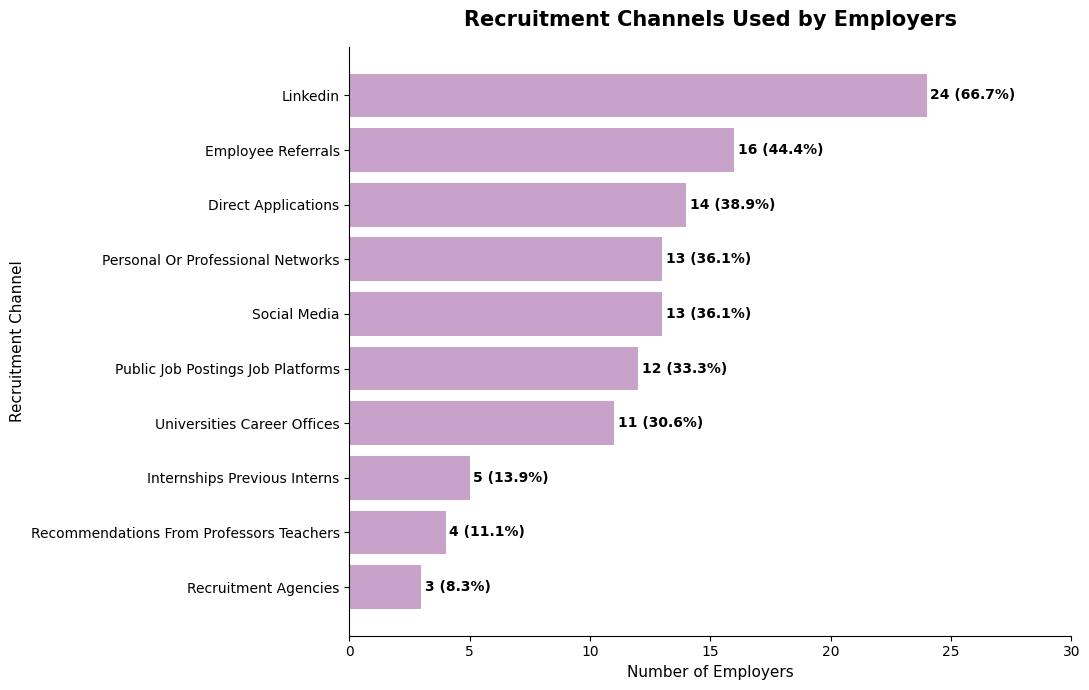

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# Recruitment Sources — Multi-response Dummy Variables
# =========================================================

recruitment_cols = [
    "recruitment_sources__direct_applications",
    "recruitment_sources__employee_referrals",
    "recruitment_sources__internships_previous_interns",
    "recruitment_sources__linkedin",
    "recruitment_sources__personal_or_professional_networks",
    "recruitment_sources__public_job_postings_job_platforms",
    "recruitment_sources__recommendations_from_professors_teachers",
    "recruitment_sources__recruitment_agencies",
    "recruitment_sources__social_media",
    "recruitment_sources__universities_career_offices"
]

# Count selections
counts = df_employer[recruitment_cols].sum()

# Total employers
n_employers = df_employer.shape[0]

# Percentages
percentages = counts / n_employers * 100

# Clean labels
labels = [
    col.replace("recruitment_sources__", "")
       .replace("_", " ")
       .title()
    for col in recruitment_cols
]

# Summary table
recruitment_summary = pd.DataFrame({
    "Recruitment Source": labels,
    "Count": counts.values,
    "Percentage": percentages.values
})

# Sort highest to lowest
recruitment_summary = recruitment_summary.sort_values(
    "Count",
    ascending=False
).reset_index(drop=True)

print(recruitment_summary)


# =========================================================
# CHART
# =========================================================

fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.barh(
    recruitment_summary["Recruitment Source"],
    recruitment_summary["Count"],
    color="#C8A2C8"
)

ax.invert_yaxis()

# Add count + percentage
for bar, count, percentage in zip(
    bars,
    recruitment_summary["Count"],
    recruitment_summary["Percentage"]
):
    ax.text(
        bar.get_width() + 0.15,
        bar.get_y() + bar.get_height() / 2,
        f"{int(count)} ({percentage:.1f}%)",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold"
    )

ax.set_title(
    "Recruitment Channels Used by Employers",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Number of Employers",
    fontsize=11
)

ax.set_ylabel(
    "Recruitment Channel",
    fontsize=11
)

ax.set_xlim(
    0,
    recruitment_summary["Count"].max() * 1.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "figures/employer_recruitment_sources.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

                           Factor  Count  Percentage
0            Communication Skills     21   58.333333
1   Technical Job Specific Skills     20   55.555556
2         Problem Solving Ability     12   33.333333
3                Education Degree     10   27.777778
4                      Motivation     10   27.777778
5   Ability To Learn Adaptability      9   25.000000
6        Previous Work Experience      6   16.666667
7    Practical Projects Portfolio      4   11.111111
8                 Professionalism      4   11.111111
9         Referral Recommendation      3    8.333333
10          Internship Experience      3    8.333333
11        English Language Skills      2    5.555556
12       Availability Flexibility      1    2.777778
13           Professional Network      1    2.777778
14            Salary Expectations      1    2.777778
15            University Attended      1    2.777778


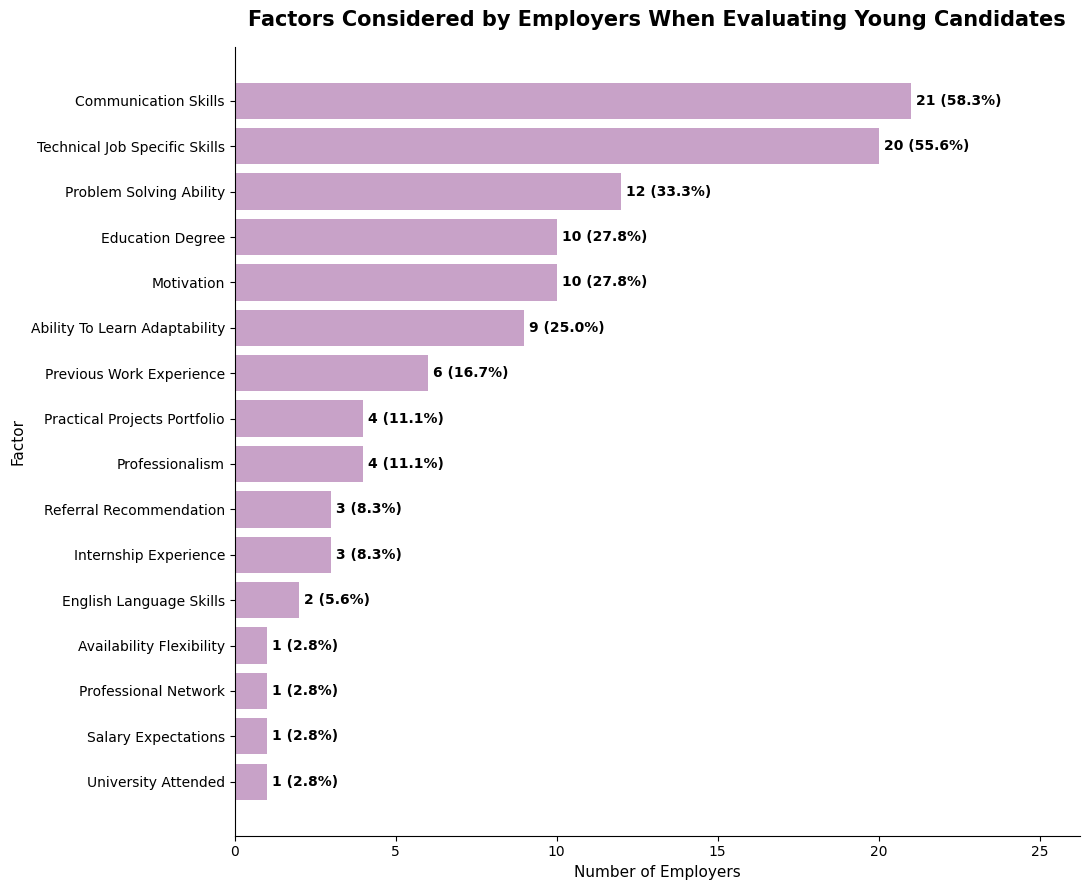

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# What Employers Look For — Multi-response Dummy Variables
# =========================================================

interview_cols = [
    "top_interview_factors__ability_to_learn_adaptability",
    "top_interview_factors__availability_flexibility",
    "top_interview_factors__communication_skills",
    "top_interview_factors__education_degree",
    "top_interview_factors__english_language_skills",
    "top_interview_factors__internship_experience",
    "top_interview_factors__motivation",
    "top_interview_factors__practical_projects_portfolio",
    "top_interview_factors__previous_work_experience",
    "top_interview_factors__problem_solving_ability",
    "top_interview_factors__professional_network",
    "top_interview_factors__professionalism",
    "top_interview_factors__referral_recommendation",
    "top_interview_factors__salary_expectations",
    "top_interview_factors__technical_job_specific_skills",
    "top_interview_factors__university_attended"
]

# Count how many employers selected each factor
counts = df_employer[interview_cols].sum()

# Total number of employers
n_employers = df_employer.shape[0]

# Calculate percentages
percentages = counts / n_employers * 100

# Create readable labels
labels = [
    col.replace("top_interview_factors__", "")
       .replace("_", " ")
       .title()
    for col in interview_cols
]

# Create summary table
interview_summary = pd.DataFrame({
    "Factor": labels,
    "Count": counts.values,
    "Percentage": percentages.values
})

# Sort from highest to lowest
interview_summary = interview_summary.sort_values(
    "Count",
    ascending=False
).reset_index(drop=True)

# Display results
print(interview_summary)


# =========================================================
# Visualization
# =========================================================

fig, ax = plt.subplots(figsize=(11, 9))

bars = ax.barh(
    interview_summary["Factor"],
    interview_summary["Count"],
    color="#C8A2C8"
)

ax.invert_yaxis()

# Add count and percentage labels
for bar, count, percentage in zip(
    bars,
    interview_summary["Count"],
    interview_summary["Percentage"]
):
    ax.text(
        bar.get_width() + 0.15,
        bar.get_y() + bar.get_height() / 2,
        f"{int(count)} ({percentage:.1f}%)",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold"
    )

ax.set_title(
    "Factors Considered by Employers When Evaluating Young Candidates",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Number of Employers",
    fontsize=11
)

ax.set_ylabel(
    "Factor",
    fontsize=11
)

ax.set_xlim(
    0,
    interview_summary["Count"].max() * 1.25
)

# Clean appearance
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "figures/employer_interview_factors.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [37]:
import pandas as pd

# =========================================================
# Importance Ratings — Mode Imputation + Median
# =========================================================

importance_cols = [
    "importance_technical_skills",
    "importance_practical_experience",
    "importance_communication",
    "importance_problem_solving",
    "importance_ability_to_learn",
    "importance_degree",
    "importance_previous_internship",
    "importance_language_skills"
]

# Correct ordinal order
importance_order = [
    "not important",
    "slightly important",
    "moderately important",
    "very important",
    "extremely important"
]

median_results = []

for col in importance_cols:

    # -----------------------------------------------------
    # 1. Calculate the mode of the feature
    # -----------------------------------------------------
    mode_value = df_employer[col].mode(dropna=True)[0]

    # -----------------------------------------------------
    # 2. Replace missing values with the feature's mode
    # -----------------------------------------------------
    df_employer[col] = df_employer[col].fillna(mode_value)

    # -----------------------------------------------------
    # 3. Convert to ordered categorical
    # -----------------------------------------------------
    ordered = pd.Categorical(
        df_employer[col],
        categories=importance_order,
        ordered=True
    )

    # -----------------------------------------------------
    # 4. Convert ordered categories to numeric codes
    # -----------------------------------------------------
    codes = pd.Series(ordered.codes)

    # Check for unexpected values
    if (codes == -1).any():
        print(f"WARNING: Unexpected values found in {col}")
        print(df_employer.loc[codes == -1, col].value_counts())

    # Remove any unrecognized values
    codes = codes[codes != -1]

    # -----------------------------------------------------
    # 5. Calculate median
    # -----------------------------------------------------
    median_code = codes.median()

    # -----------------------------------------------------
    # 6. Convert median code back to category
    # -----------------------------------------------------
    median_category = importance_order[int(median_code)]

    # -----------------------------------------------------
    # 7. Store results
    # -----------------------------------------------------
    factor_name = (
        col.replace("importance_", "")
           .replace("_", " ")
           .title()
    )

    median_results.append({
        "Factor": factor_name,
        "Mode Used for Missing": mode_value,
        "Median": median_category
    })


# =========================================================
# Final Results
# =========================================================

median_summary = pd.DataFrame(median_results)

print("=" * 80)
print("EMPLOYER IMPORTANCE RATINGS — MEDIAN ANALYSIS")
print("=" * 80)

print(median_summary.to_string(index=False))

EMPLOYER IMPORTANCE RATINGS — MEDIAN ANALYSIS
              Factor Mode Used for Missing               Median
    Technical Skills        very important       very important
Practical Experience  moderately important moderately important
       Communication   extremely important       very important
     Problem Solving  moderately important       very important
    Ability To Learn   extremely important  extremely important
              Degree  moderately important moderately important
 Previous Internship  moderately important moderately important
     Language Skills        very important       very important


WHY YOUNG CANDIDATES ARE REJECTED
                                      Reason  Count  Percentage
                   Weak Communication Skills     18   50.000000
Insufficient Technical / Job-Specific Skills     16   44.444444
                Lack of Practical Experience     14   38.888889
                     Lack of Professionalism     10   27.777778
                  Poor Interview Performance      9   25.000000
                          Lack of Motivation      7   19.444444
           Education Does Not Match Position      6   16.666667
                Weak English Language Skills      6   16.666667
            Lack of Previous Work Experience      6   16.666667
                         Salary Expectations      4   11.111111
                Lack of Long-Term Commitment      3    8.333333
                   Location / Transportation      3    8.333333
Employer Needed a More Experienced Candidate      2    5.555556
                Availability / Working Hours      2    5.555556
      

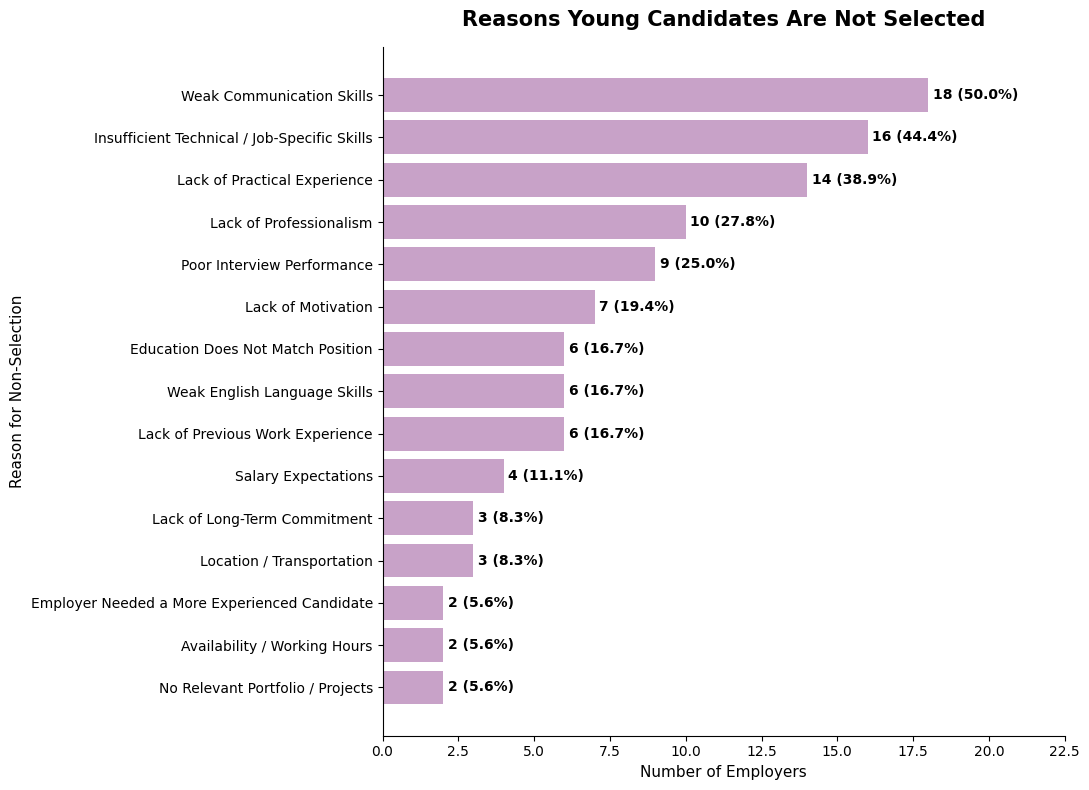

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# Why Young Candidates Are Rejected
# Multi-response analysis
# =========================================================

rejection_cols = [
    "reasons_not_selected__availability_working_hours",
    "reasons_not_selected__education_does_not_match_the_position",
    "reasons_not_selected__employer_needed_a_more_experienced_candidate",
    "reasons_not_selected__insufficient_technical_job_specific_skills",
    "reasons_not_selected__lack_of_long_term_commitment",
    "reasons_not_selected__lack_of_motivation",
    "reasons_not_selected__lack_of_practical_experience",
    "reasons_not_selected__lack_of_previous_work_experience",
    "reasons_not_selected__lack_of_professionalism",
    "reasons_not_selected__location_transportation",
    "reasons_not_selected__no_relevant_portfolio_projects",
    "reasons_not_selected__poor_interview_performance",
    "reasons_not_selected__salary_expectations",
    "reasons_not_selected__weak_communication_skills",
    "reasons_not_selected__weak_english_language_skills"
]

# =========================================================
# 1. Calculate counts
# =========================================================

counts = df_employer[rejection_cols].sum()

# Total number of employers
n_employers = len(df_employer)

# Calculate percentages
percentages = (counts / n_employers) * 100

# =========================================================
# 2. Create readable labels
# =========================================================

labels = {
    "reasons_not_selected__availability_working_hours":
        "Availability / Working Hours",

    "reasons_not_selected__education_does_not_match_the_position":
        "Education Does Not Match Position",

    "reasons_not_selected__employer_needed_a_more_experienced_candidate":
        "Employer Needed a More Experienced Candidate",

    "reasons_not_selected__insufficient_technical_job_specific_skills":
        "Insufficient Technical / Job-Specific Skills",

    "reasons_not_selected__lack_of_long_term_commitment":
        "Lack of Long-Term Commitment",

    "reasons_not_selected__lack_of_motivation":
        "Lack of Motivation",

    "reasons_not_selected__lack_of_practical_experience":
        "Lack of Practical Experience",

    "reasons_not_selected__lack_of_previous_work_experience":
        "Lack of Previous Work Experience",

    "reasons_not_selected__lack_of_professionalism":
        "Lack of Professionalism",

    "reasons_not_selected__location_transportation":
        "Location / Transportation",

    "reasons_not_selected__no_relevant_portfolio_projects":
        "No Relevant Portfolio / Projects",

    "reasons_not_selected__poor_interview_performance":
        "Poor Interview Performance",

    "reasons_not_selected__salary_expectations":
        "Salary Expectations",

    "reasons_not_selected__weak_communication_skills":
        "Weak Communication Skills",

    "reasons_not_selected__weak_english_language_skills":
        "Weak English Language Skills"
}

# =========================================================
# 3. Create summary table
# =========================================================

rejection_summary = pd.DataFrame({
    "Reason": counts.index.map(labels),
    "Count": counts.values,
    "Percentage": percentages.values
})

# Sort from highest to lowest
rejection_summary = rejection_summary.sort_values(
    "Count",
    ascending=False
).reset_index(drop=True)

print("=" * 80)
print("WHY YOUNG CANDIDATES ARE REJECTED")
print("=" * 80)

print(rejection_summary.to_string(index=False))

# =========================================================
# 4. Create horizontal bar chart
# =========================================================

fig, ax = plt.subplots(figsize=(11, 8))

bars = ax.barh(
    rejection_summary["Reason"],
    rejection_summary["Count"],
    color="#C8A2C8"
)

ax.invert_yaxis()

# Add count + percentage labels
for bar, count, percentage in zip(
    bars,
    rejection_summary["Count"],
    rejection_summary["Percentage"]
):
    ax.text(
        bar.get_width() + 0.15,
        bar.get_y() + bar.get_height() / 2,
        f"{int(count)} ({percentage:.1f}%)",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold"
    )

# =========================================================
# 5. Formatting
# =========================================================

ax.set_title(
    "Reasons Young Candidates Are Not Selected",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Number of Employers",
    fontsize=11
)

ax.set_ylabel(
    "Reason for Non-Selection",
    fontsize=11
)

max_count = rejection_summary["Count"].max()

ax.set_xlim(
    0,
    max_count * 1.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# =========================================================
# 6. Save figure
# =========================================================

plt.savefig(
    "figures/employer_rejection_reasons.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

EMPLOYER HIRING BARRIERS
                                                              Challenge  Count  Percentage
                               Many Applicants but Few Met Requirements     25   69.444444
                           Candidates Lacked the Experience We Expected     18   50.000000
                                 Candidates Lacked the Skills We Needed     16   44.444444
                Candidates Expected Higher Salaries Than We Could Offer     16   44.444444
                                Suitable Candidates Declined Our Offers     11   30.555556
Candidates Unavailable Due to Location / Transportation / Working Hours      9   25.000000
                            Suitable Candidates Accepted but Later Left      5   13.888889
                                                     Too Few Applicants      2    5.555556


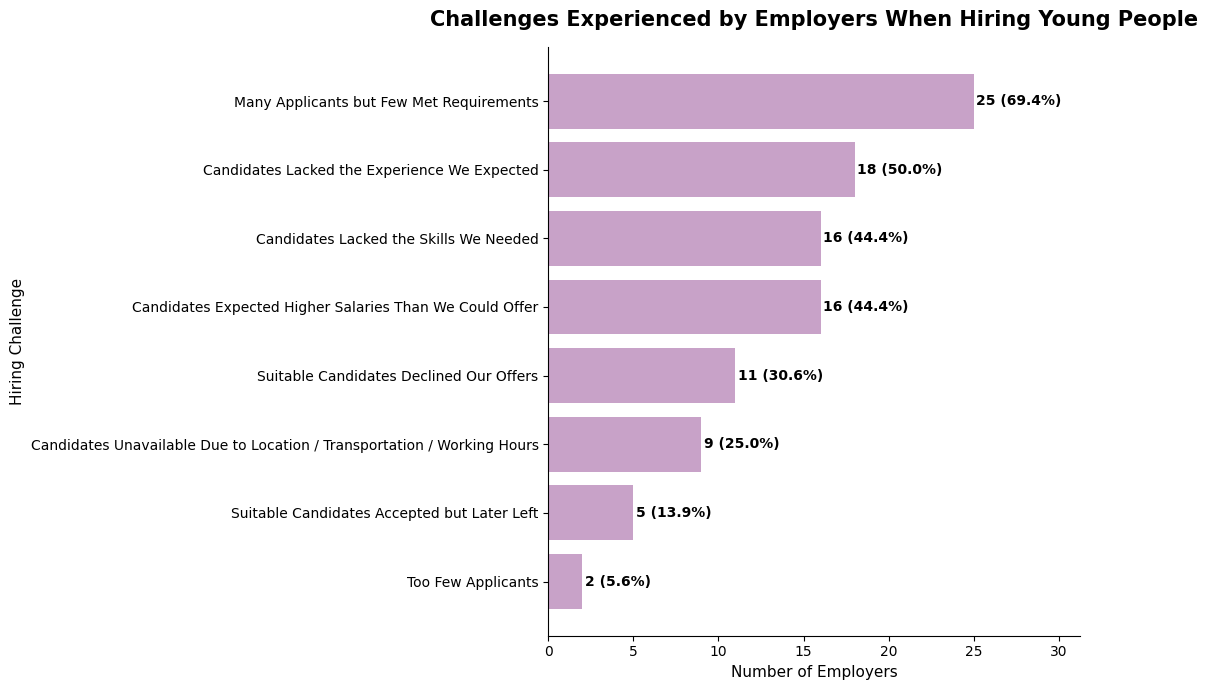

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# Employer Hiring Barriers
# Multi-response analysis
# =========================================================

hiring_challenge_cols = [
    "hiring_challenges__candidates_expected_higher_salaries_than_we_could_offer",
    "hiring_challenges__candidates_lacked_the_experience_we_expected",
    "hiring_challenges__candidates_lacked_the_skills_we_needed",
    "hiring_challenges__candidates_were_unavailable_because_of_location_transportation_or_working_hours",
    "hiring_challenges__suitable_candidates_accepted_but_later_left",
    "hiring_challenges__suitable_candidates_declined_our_offers",
    "hiring_challenges__we_received_many_applicants_but_few_met_our_requirements",
    "hiring_challenges__we_received_too_few_applicants"
]

# =========================================================
# 1. Calculate counts and percentages
# =========================================================

counts = df_employer[hiring_challenge_cols].sum()

n_employers = len(df_employer)

percentages = (counts / n_employers) * 100

# =========================================================
# 2. Readable labels
# =========================================================

labels = {
    "hiring_challenges__candidates_expected_higher_salaries_than_we_could_offer":
        "Candidates Expected Higher Salaries Than We Could Offer",

    "hiring_challenges__candidates_lacked_the_experience_we_expected":
        "Candidates Lacked the Experience We Expected",

    "hiring_challenges__candidates_lacked_the_skills_we_needed":
        "Candidates Lacked the Skills We Needed",

    "hiring_challenges__candidates_were_unavailable_because_of_location_transportation_or_working_hours":
        "Candidates Unavailable Due to Location / Transportation / Working Hours",

    "hiring_challenges__suitable_candidates_accepted_but_later_left":
        "Suitable Candidates Accepted but Later Left",

    "hiring_challenges__suitable_candidates_declined_our_offers":
        "Suitable Candidates Declined Our Offers",

    "hiring_challenges__we_received_many_applicants_but_few_met_our_requirements":
        "Many Applicants but Few Met Requirements",

    "hiring_challenges__we_received_too_few_applicants":
        "Too Few Applicants"
}

# =========================================================
# 3. Create summary table
# =========================================================

hiring_challenge_summary = pd.DataFrame({
    "Challenge": counts.index.map(labels),
    "Count": counts.values,
    "Percentage": percentages.values
})

# Sort highest to lowest
hiring_challenge_summary = (
    hiring_challenge_summary
    .sort_values("Count", ascending=False)
    .reset_index(drop=True)
)

# Display results
print("=" * 80)
print("EMPLOYER HIRING BARRIERS")
print("=" * 80)

print(hiring_challenge_summary.to_string(index=False))

# =========================================================
# 4. Create horizontal bar chart
# =========================================================

fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.barh(
    hiring_challenge_summary["Challenge"],
    hiring_challenge_summary["Count"],
    color="#C8A2C8"
)

ax.invert_yaxis()

# Add count + percentage labels
for bar, count, percentage in zip(
    bars,
    hiring_challenge_summary["Count"],
    hiring_challenge_summary["Percentage"]
):
    ax.text(
        bar.get_width() + 0.15,
        bar.get_y() + bar.get_height() / 2,
        f"{int(count)} ({percentage:.1f}%)",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold"
    )

# =========================================================
# 5. Formatting
# =========================================================

ax.set_title(
    "Challenges Experienced by Employers When Hiring Young People",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Number of Employers",
    fontsize=11
)

ax.set_ylabel(
    "Hiring Challenge",
    fontsize=11
)

max_count = hiring_challenge_summary["Count"].max()

ax.set_xlim(
    0,
    max_count * 1.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# =========================================================
# 6. Save figure
# =========================================================

plt.savefig(
    "figures/employer_hiring_challenges.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


expected_previous_experience
expected_previous_experience
less than 1 year                    11
1–2 years                            9
no experience                        6
depends strongly on the position     6
2–3 years                            4
Name: count, dtype: int64

importance_connections
importance_connections
very important                                       12
extremely important                                   7
moderately important                                  7
slightly important                                    5
we mainly use open / public recruitment processes     4
not important at all                                  1
Name: count, dtype: int64

unnecessary_requirements
unnecessary_requirements
sometimes                  13
depends on the position     7
often                       6
very often                  4
rarely                      3
not sure                    2
never                       1
Name: count, dtype: int64

response_to_skill_gap
r

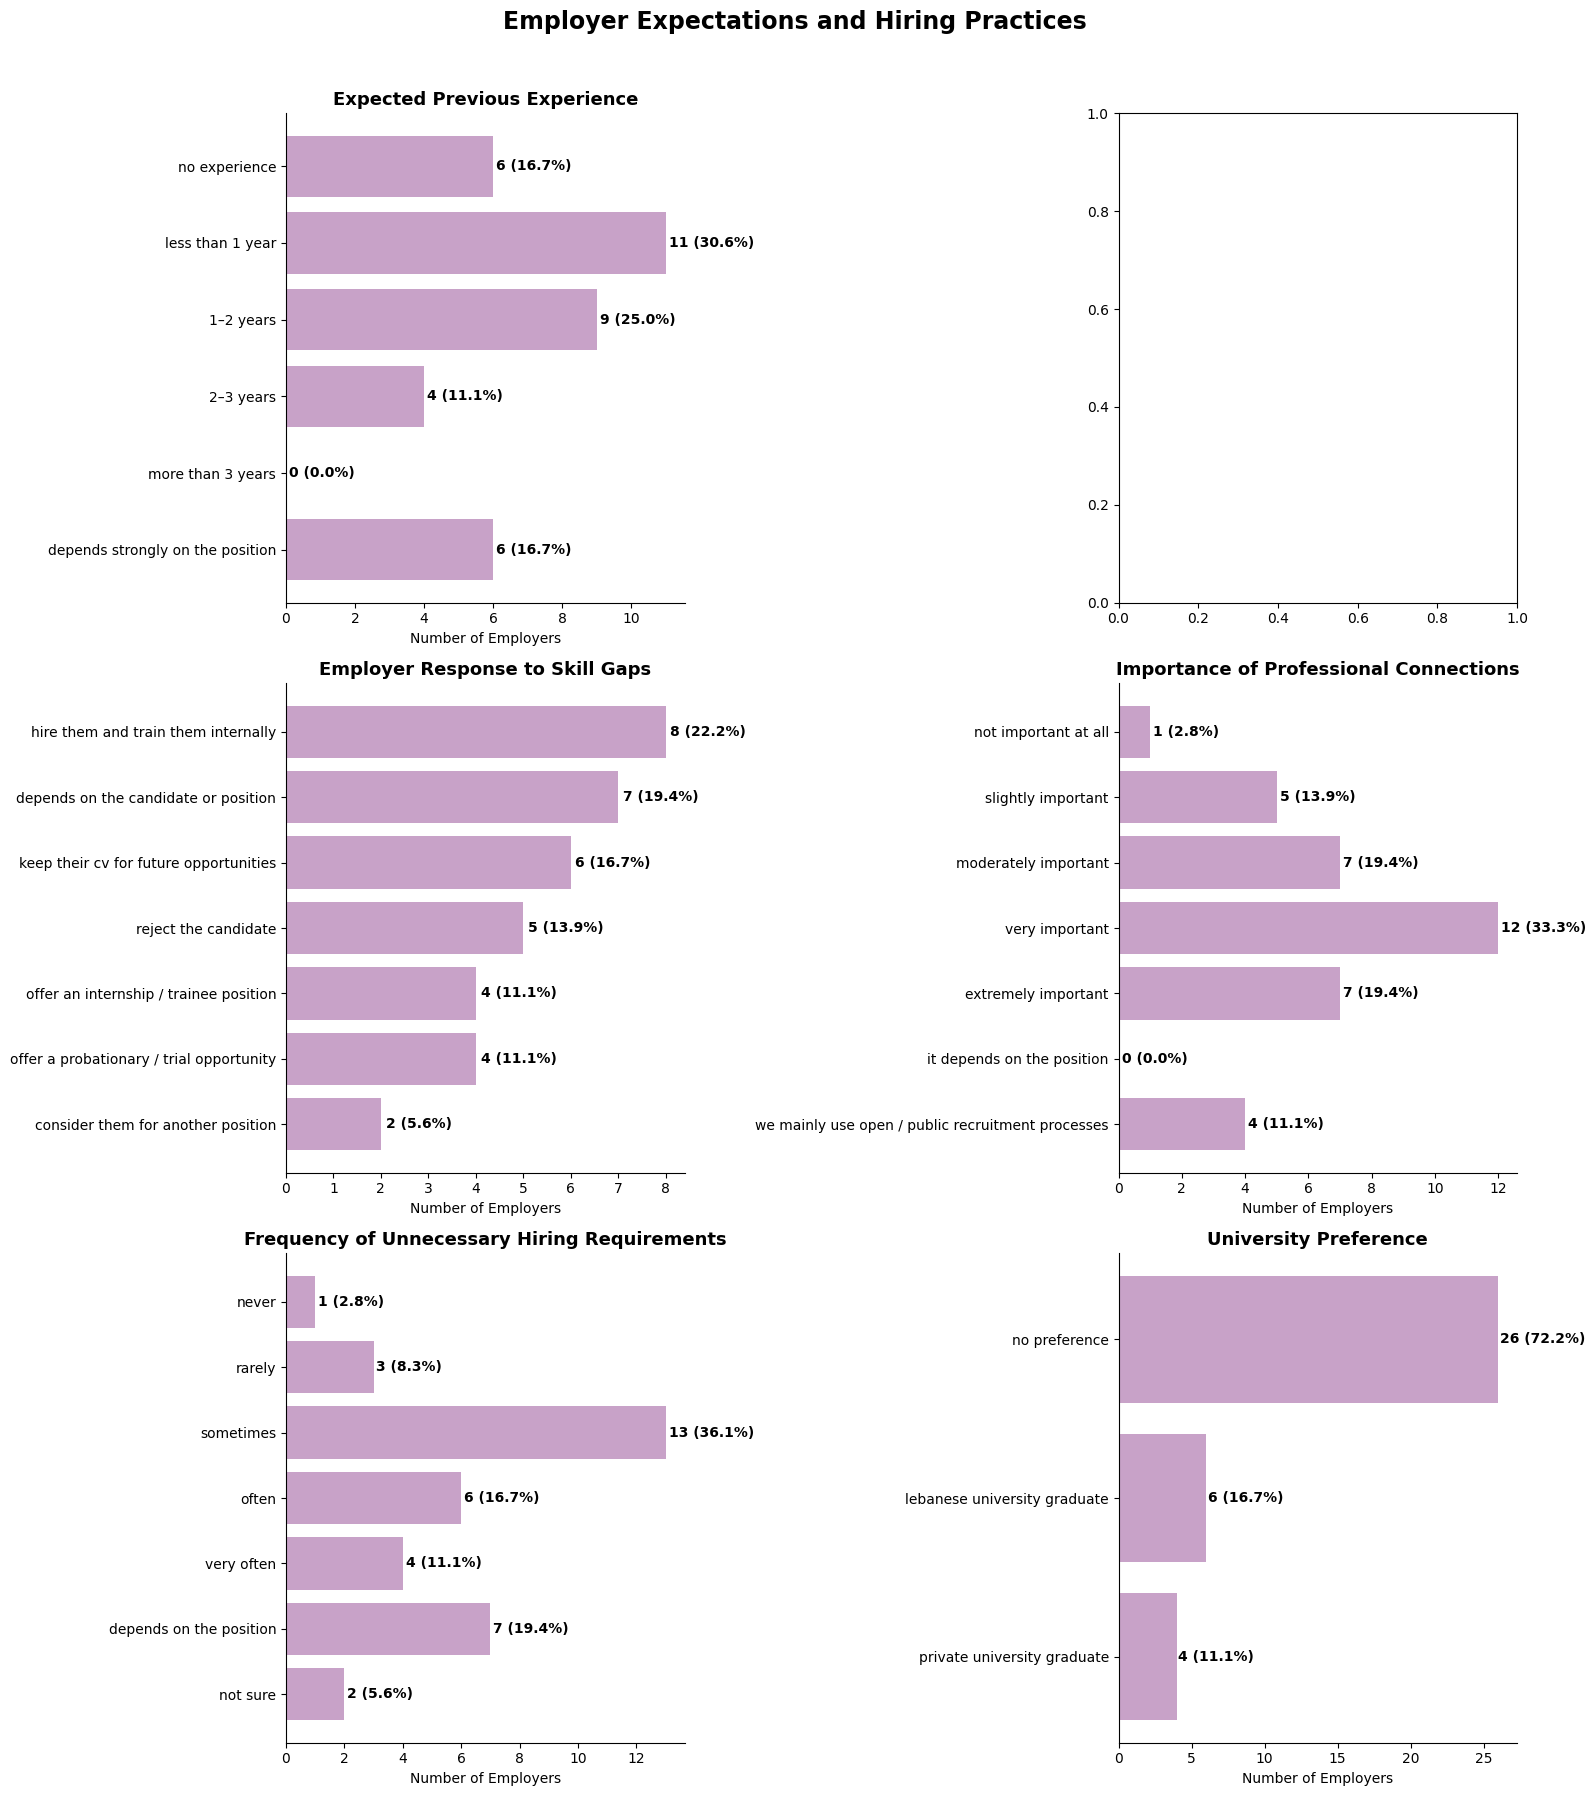

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# Employer Expectations and Practices
# =========================================================

ordinal_cols = [
    "expected_previous_experience",
    
    "importance_connections",
    "unnecessary_requirements"
]

categorical_cols = [
    "response_to_skill_gap",
    "university_preference"
]

# =========================================================
# 1. Inspect the actual values
# =========================================================

for col in ordinal_cols + categorical_cols:
    print("\n" + "=" * 70)
    print(col)
    print("=" * 70)
    print(df_employer[col].value_counts(dropna=False))


# =========================================================
# 2. Ordinal category orders
# =========================================================

ordinal_orders = {

    "expected_previous_experience": [
        "no experience",
        "less than 1 year",
        "1–2 years",
        "2–3 years",
        "more than 3 years",
        "depends strongly on the position"
    ],

    
    "importance_connections": [
        "not important at all",
        "slightly important",
        "moderately important",
        "very important",
        "extremely important",
        "it depends on the position",
        "we mainly use open / public recruitment processes"
    ],

    "unnecessary_requirements": [
        "never",
        "rarely",
        "sometimes",
        "often",
        "very often",
        "depends on the position",
        "not sure"
    ]
}


# =========================================================
# 3. Calculate medians with mode imputation
# =========================================================

median_results = []

for col in ordinal_cols:

    # Normalize actual responses
    s = (
        df_employer[col]
        .astype("string")
        .str.strip()
        .str.lower()
    )

    # Mode imputation
    if s.dropna().empty:
        print(f"\nNo valid data for: {col}")
        continue

    mode_value = s.mode().iloc[0]

    s = s.fillna(mode_value)

    # Get the expected ordinal order
    order = ordinal_orders[col]

    # Convert categories to ordinal scores
    score_mapping = {
        category: i + 1
        for i, category in enumerate(order)
    }

    scores = s.map(score_mapping)

    # Check unmatched values
    if scores.isna().any():

        print(f"\nWARNING — unmatched values in {col}:")
        print(s[scores.isna()].unique())

        print("\nExpected categories:")
        print(order)

        continue

    # Calculate median
    median_score = scores.median()

    median_category = order[int(median_score) - 1]

    median_results.append({
        "Variable": col,
        "Median Score": median_score,
        "Median Category": median_category
    })


# Create summary
median_summary = pd.DataFrame(median_results)


# =========================================================
# 4. Display median results
# =========================================================

print("\n" + "=" * 80)
print("MEDIAN RESULTS")
print("=" * 80)

if not median_summary.empty:
    print(median_summary.to_string(index=False))
else:
    print("No median results were generated.")
    print("Check the unmatched categories printed above.")


# =========================================================
# 5. Create figure
# =========================================================

fig, axes = plt.subplots(
    3,
    2,
    figsize=(16, 18)
)

axes = axes.flatten()


# ---------------------------------------------------------
# Function for ordinal charts
# ---------------------------------------------------------

def plot_ordinal(ax, col, title):

    s = (
        df_employer[col]
        .astype("string")
        .str.strip()
        .str.lower()
    )

    # Mode imputation
    mode_value = s.mode().iloc[0]
    s = s.fillna(mode_value)

    order = ordinal_orders[col]

    counts = s.value_counts().reindex(
        order,
        fill_value=0
    )

    percentages = (
        counts / counts.sum() * 100
    )

    bars = ax.barh(
        order,
        counts,
        color="#C8A2C8"
    )

    ax.invert_yaxis()

    ax.set_title(
        title,
        fontsize=13,
        fontweight="bold"
    )

    ax.set_xlabel("Number of Employers")

    for bar, count, percentage in zip(
        bars,
        counts,
        percentages
    ):

        ax.text(
            bar.get_width() + 0.1,
            bar.get_y() + bar.get_height() / 2,
            f"{int(count)} ({percentage:.1f}%)",
            va="center",
            fontsize=10,
            fontweight="bold"
        )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


# =========================================================
# 6. Plot ordinal variables
# =========================================================

plot_ordinal(
    axes[0],
    "expected_previous_experience",
    "Expected Previous Experience"
)



plot_ordinal(
    axes[3],
    "importance_connections",
    "Importance of Professional Connections"
)

plot_ordinal(
    axes[4],
    "unnecessary_requirements",
    "Frequency of Unnecessary Hiring Requirements"
)


# =========================================================
# 7. Categorical variables
# =========================================================

def plot_categorical(ax, col, title):

    s = df_employer[col].fillna("Missing")

    counts = s.value_counts()

    percentages = (
        counts / counts.sum() * 100
    )

    bars = ax.barh(
        counts.index,
        counts.values,
        color="#C8A2C8"
    )

    ax.invert_yaxis()

    ax.set_title(
        title,
        fontsize=13,
        fontweight="bold"
    )

    ax.set_xlabel("Number of Employers")

    for bar, count, percentage in zip(
        bars,
        counts,
        percentages
    ):

        ax.text(
            bar.get_width() + 0.1,
            bar.get_y() + bar.get_height() / 2,
            f"{int(count)} ({percentage:.1f}%)",
            va="center",
            fontsize=10,
            fontweight="bold"
        )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


plot_categorical(
    axes[2],
    "response_to_skill_gap",
    "Employer Response to Skill Gaps"
)

plot_categorical(
    axes[5],
    "university_preference",
    "University Preference"
)


# =========================================================
# 8. Overall formatting
# =========================================================

plt.suptitle(
    "Employer Expectations and Hiring Practices",
    fontsize=17,
    fontweight="bold",
    y=0.995
)

plt.tight_layout(
    rect=[0, 0, 1, 0.98]
)

plt.savefig(
    "figures/employer_expectations.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# Practical Solutions Chosen by Employers
# =========================================================

solution_cols = [
    
    "employment_improvements__better_salaries_compensation",
    "employment_improvements__better_working_conditions",
    "employment_improvements__career_guidance",
    "employment_improvements__employer_linked_training",
    "employment_improvements__entrepreneurship_support",
    "employment_improvements__government_incentives_for_employers",
    "employment_improvements__internships_apprenticeships",
    "employment_improvements__interview_preparation",
    "employment_improvements__job_placement_job_matching",
    "employment_improvements__job_specific_training",
    "employment_improvements__mentorship",
    "employment_improvements__professional_networking_opportunities",
    "employment_improvements__university_employer_partnerships"
]


# Count how many employers selected each solution
counts = df_employer[solution_cols].sum()

# Total number of employers
n_employers = len(df_employer)

# Calculate percentage
percentages = (counts / n_employers) * 100

# Create summary table
solution_summary = pd.DataFrame({
    "Solution": counts.index,
    "Count": counts.values,
    "Percentage": percentages.values
})

# Clean labels
solution_summary["Solution"] = (
    solution_summary["Solution"]
    .str.replace("employment_improvements__", "", regex=False)
    .str.replace("_", " ")
    .str.title()
)

# Sort from most to least selected
solution_summary = solution_summary.sort_values(
    "Count",
    ascending=False
).reset_index(drop=True)

print(solution_summary)

                                 Solution  Count  Percentage
0            Better Salaries Compensation     15   41.666667
1                         Career Guidance     13   36.111111
2             Internships Apprenticeships     11   30.555556
3        University Employer Partnerships     10   27.777778
4                   Job Specific Training      9   25.000000
5                              Mentorship      9   25.000000
6   Professional Networking Opportunities      8   22.222222
7               Better Working Conditions      5   13.888889
8                   Interview Preparation      5   13.888889
9              Job Placement Job Matching      5   13.888889
10               Employer Linked Training      3    8.333333
11    Government Incentives For Employers      3    8.333333
12               Entrepreneurship Support      2    5.555556
